In [1]:
import os
import re
import xml.etree.ElementTree as ET

from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

%matplotlib inline


In [2]:
def natural_key(s):
    """Sort strings the human way: d-2 before d-10."""
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', s)]

def ask_choice(prompt, n):
    """Ask for a number between 1 and n, re-asking until it's valid."""
    while True:
        raw = input(prompt).strip()
        if raw.isdigit() and 1 <= int(raw) <= n:
            return int(raw) - 1
        print(f"Please enter a number between 1 and {n}.")


In [10]:
BASE_DIR = os.getcwd()

folders = sorted(
    [d for d in os.listdir(BASE_DIR)
     if os.path.isdir(os.path.join(BASE_DIR, d)) and not d.startswith('.')],
    key=natural_key,
)

if not folders:
    raise SystemExit("No sub-folders found next to this notebook. "
                      "Make sure it sits inside the dataset folder.")

print("Choose a folder:\n")
for i, f in enumerate(folders, start=1):
    print(f"{i} - {f}")

folder_idx = ask_choice(f"\nEnter a number (1-{len(folders)}): ", len(folders))
chosen_folder = folders[folder_idx]
FOLDER_PATH = os.path.join(BASE_DIR, chosen_folder)

print(f"\nSelected folder: {chosen_folder}")


Choose a folder:

1 - Charts
2 - graphics
3 - Headers
4 - multi-columns
5 - tables
6 - text and images
7 - textonly
8 - titles

Selected folder: multi-columns


In [11]:
all_files = os.listdir(FOLDER_PATH)
image_files = sorted(
    [f for f in all_files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))],
    key=natural_key,
)

pairs = []
for img_f in image_files:
    base = os.path.splitext(img_f)[0]
    xml_candidates = [f for f in all_files
                       if os.path.splitext(f)[0] == base and f.lower().endswith('.xml')]
    if xml_candidates:
        pairs.append((img_f, xml_candidates[0]))

if not pairs:
    raise SystemExit(f"No matching image + .xml pairs found in '{chosen_folder}'.")

print(f"Images available in '{chosen_folder}':\n")
for i, (img_f, xml_f) in enumerate(pairs, start=1):
    print(f"{i} - {img_f}")

img_idx = ask_choice(f"\nChoose an image (1-{len(pairs)}): ", len(pairs))
chosen_img, chosen_xml = pairs[img_idx]
IMAGE_PATH = os.path.join(FOLDER_PATH, chosen_img)
XML_PATH = os.path.join(FOLDER_PATH, chosen_xml)

print(f"\nSelected image: {chosen_img}")
print(f"Matching annotation: {chosen_xml}")


Images available in 'multi-columns':

1 - Charts-14.jpg
2 - d-0.jpg
3 - d-1.jpg
4 - d-2.jpg
5 - d-3.jpg
6 - d-4.jpg
7 - e-0.jpg
8 - e-1.jpg
9 - e-2.jpg
10 - e-3.jpg
11 - e-4.jpg
12 - multicolumn-0.jpg
13 - multicolumn-1.jpg
14 - multicolumn-2.jpg
15 - multicolumn-3.jpg
16 - multicolumn-4.jpg
17 - multicolumn-5.jpg
18 - multicolumn-6.jpg
19 - multicolumn-7.jpg
20 - multicolumn-8.jpg
21 - multicolumn-9.jpg
22 - multicolumn-10.jpg
23 - multicolumn-11.jpg
24 - multicolumn-12.jpg
25 - multicolumn-13.jpg
26 - multicolumn-14.jpg
27 - multicolumn-16.jpg
28 - multicolumn-17.jpg
29 - multicolumn-18.jpg

Selected image: e-0.jpg
Matching annotation: e-0.xml


In [12]:
def parse_page_xml(xml_path):
    """Return a list of {id, label, bbox} for every region in a PAGE-XML file."""
    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Handle the PAGE XML namespace automatically
    if root.tag.startswith('{'):
        ns_uri = root.tag[1:root.tag.index('}')]
        ns = {'p': ns_uri}
        page = root.find('p:Page', ns)
        coords_tag = 'p:Coords'
    else:
        ns = {}
        page = root.find('Page')
        coords_tag = 'Coords'

    regions = []
    if page is None:
        return regions

    for region in page:
        tag_name = region.tag.split('}')[-1]
        if not tag_name.endswith('Region'):
            continue  # skip ReadingOrder and other non-region nodes

        coords_el = region.find(coords_tag, ns)
        if coords_el is None or 'points' not in coords_el.attrib:
            continue

        points = [
            tuple(map(int, p.split(',')))
            for p in coords_el.attrib['points'].strip().split(' ')
            if p
        ]
        xs = [p[0] for p in points]
        ys = [p[1] for p in points]

        # Prefer the explicit "type" (paragraph, heading, header, page-number...)
        # fall back to the region tag (Table, Image, Graphic, Chart...) if absent.
        label = region.attrib.get('type', tag_name.replace('Region', '') or tag_name)

        regions.append({
            'id': region.attrib.get('id', ''),
            'label': label,
            'bbox': (min(xs), min(ys), max(xs), max(ys)),
        })

    return regions

regions = parse_page_xml(XML_PATH)
print(f"Found {len(regions)} region(s):")
for r in regions:
    print(f"  - {r['id']}: {r['label']}  bbox={r['bbox']}")


Found 24 region(s):
  - r1: header  bbox=(167, 80, 1525, 119)
  - r2: heading  bbox=(640, 161, 1545, 311)
  - r3: paragraph  bbox=(1337, 337, 1549, 861)
  - r4: Image  bbox=(868, 334, 1315, 722)
  - r5: paragraph  bbox=(1102, 723, 1314, 859)
  - r6: paragraph  bbox=(868, 725, 1078, 862)
  - r7: paragraph  bbox=(633, 329, 845, 858)
  - r8: heading  bbox=(670, 895, 1517, 982)
  - r9: paragraph  bbox=(1338, 995, 1549, 1575)
  - r10: paragraph  bbox=(1102, 995, 1313, 1577)
  - r11: paragraph  bbox=(868, 998, 1078, 1574)
  - r12: Image  bbox=(633, 997, 849, 1345)
  - r13: paragraph  bbox=(633, 1360, 843, 1574)
  - r14: heading  bbox=(726, 1605, 1452, 1694)
  - r16: paragraph  bbox=(1337, 1710, 1548, 2173)
  - r17: paragraph  bbox=(1102, 1709, 1312, 2170)
  - r18: paragraph  bbox=(867, 1709, 1077, 2168)
  - r19: paragraph  bbox=(632, 1706, 843, 2168)
  - r20: heading  bbox=(209, 182, 576, 402)
  - r21: paragraph  bbox=(401, 412, 594, 1338)
  - r22: Image  bbox=(193, 419, 383, 715)
  - r23: p

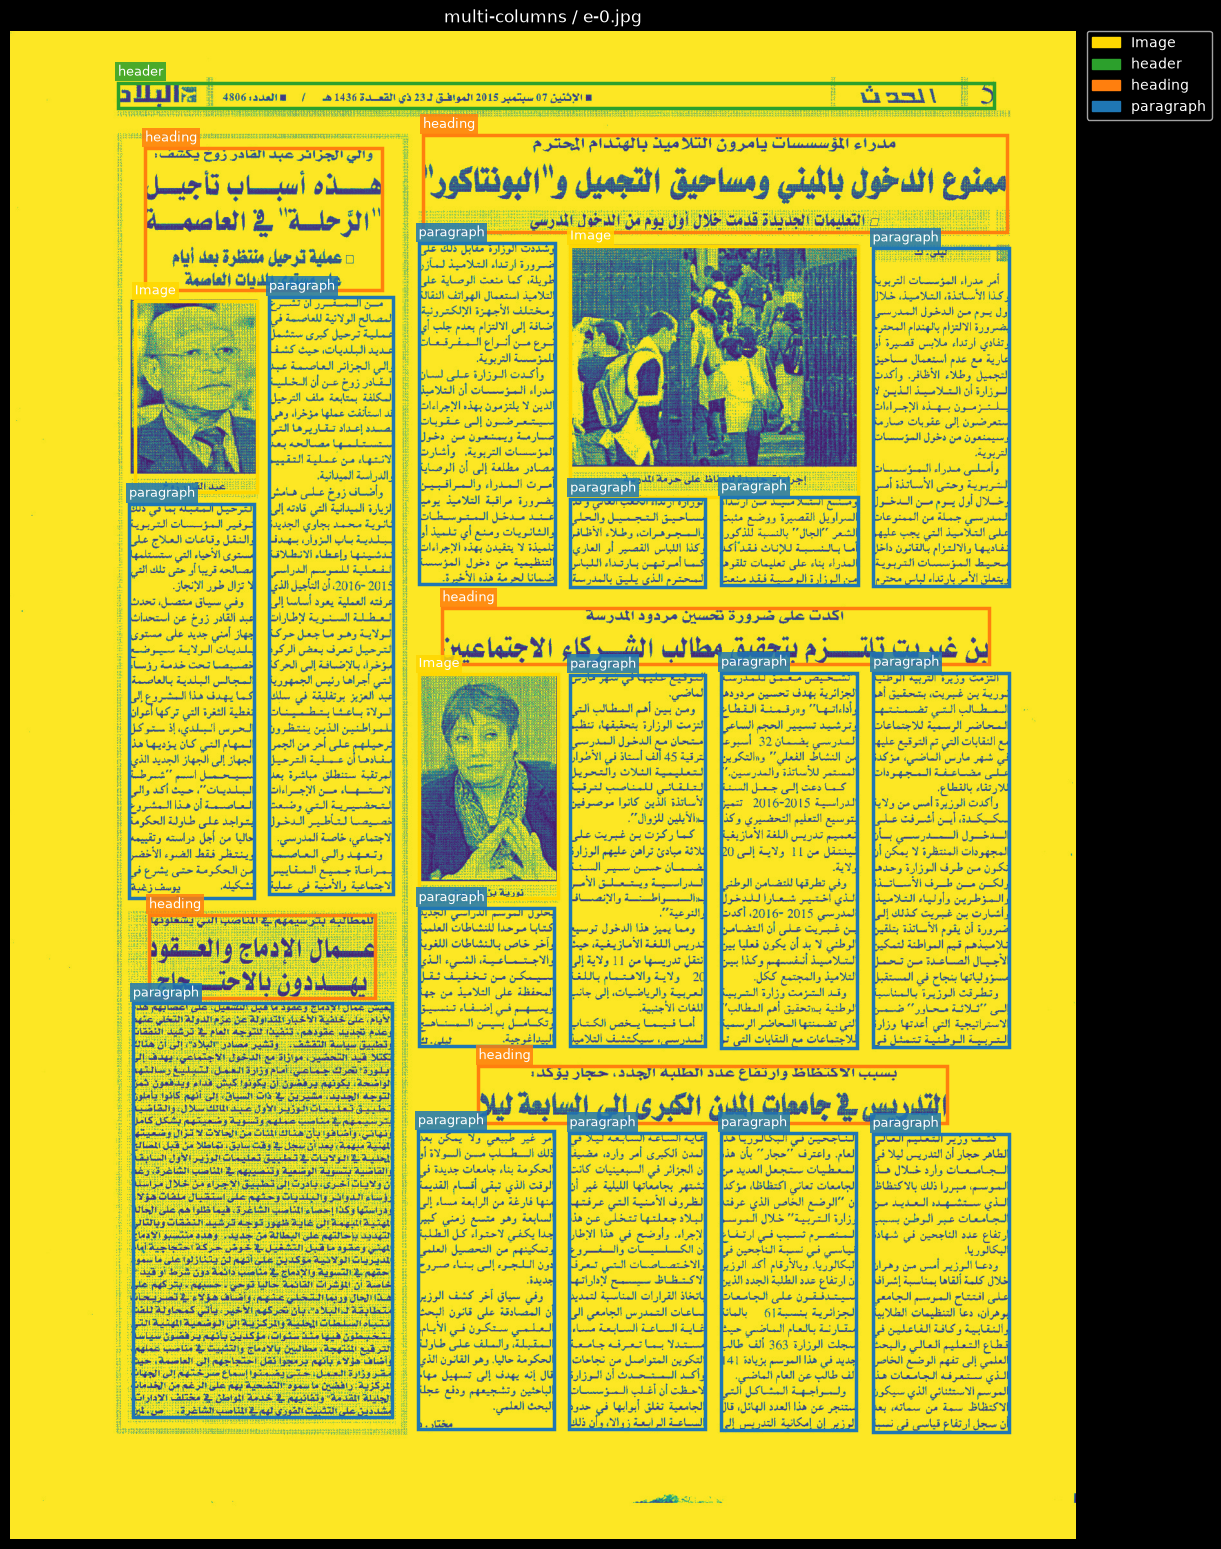

In [13]:
KNOWN_COLORS = {
    'paragraph': '#1f77b4',
    'heading': '#ff7f0e',
    'header': '#2ca02c',
    'footer': '#d62728',
    'page-number': '#9467bd',
    'caption': '#8c564b',
    'credit': '#e377c2',
    'floating': '#7f7f7f',
    'drop-capital': '#bcbd22',
    'Table': '#17becf',
    'Image': '#ffd700',
    'Graphic': '#00c853',
    'Chart': '#ff00ff',
    'LineDrawing': '#000080',
    'Separator': '#000000',
    'Noise': '#c0c0c0',
}
FALLBACK_CMAP = plt.colormaps.get_cmap('tab20')

unique_labels = sorted({r['label'] for r in regions})
color_map = {}
fallback_i = 0
for lab in unique_labels:
    if lab in KNOWN_COLORS:
        color_map[lab] = KNOWN_COLORS[lab]
    else:
        color_map[lab] = FALLBACK_CMAP(fallback_i % 20)
        fallback_i += 1

img = Image.open(IMAGE_PATH)
fig, ax = plt.subplots(figsize=(12, 16))
ax.imshow(img)

for r in regions:
    x0, y0, x1, y1 = r['bbox']
    color = color_map[r['label']]
    rect = mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                               linewidth=2.5, edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    ax.text(
        x0, max(y0 - 6, 0), r['label'],
        fontsize=9, color='white', va='bottom',
        bbox=dict(facecolor=color, alpha=0.85, pad=2, edgecolor='none'),
    )

legend_handles = [mpatches.Patch(color=color_map[l], label=l) for l in unique_labels]
ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0.)

ax.set_title(f"{chosen_folder} / {chosen_img}")
ax.axis('off')
plt.tight_layout()
plt.show()
